# NPC43 single-cell analysis, VS Code ready

Put this notebook in the same folder as the four `.gz` files, then run cells one by one.

# New section

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install scanpy anndata pandas numpy scipy matplotlib seaborn scikit-learn leidenalg igraph palantir



---



In [6]:
# 0) Package check
# In VS Code terminal, install missing packages if needed:
# pip install scanpy anndata pandas numpy scipy matplotlib seaborn scikit-learn leidenalg igraph palantir

import os
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.settings.figdir = "figures"
Path(sc.settings.figdir).mkdir(exist_ok=True)

sc.set_figure_params(dpi=150, facecolor="white", frameon=True)
plt.rcParams["pdf.fonttype"] = 42


In [45]:
# 1) Set data folder
# Keep all files in the same folder as this notebook, or change DATA_DIR manually.
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/tan")

files = {
    "matrix": "npc43_gene_exp.mtx",
    "genes": "npc43_genes.tsv",
    "barcodes": "npc43_barcodes.tsv",
    "annotation": "npc43_cell_annotation.csv",
}

for key, fname in files.items():
    fpath = DATA_DIR / fname
    print(f"{key:12s}", fpath, "FOUND" if fpath.exists() else "MISSING")


matrix       /content/drive/MyDrive/tan/npc43_gene_exp.mtx FOUND
genes        /content/drive/MyDrive/tan/npc43_genes.tsv FOUND
barcodes     /content/drive/MyDrive/tan/npc43_barcodes.tsv FOUND
annotation   /content/drive/MyDrive/tan/npc43_cell_annotation.csv FOUND


In [40]:
import importlib, gc

# Force flush Drive cache
import os
os.sync()

# Re-read the file
with open(DATA_DIR / files["genes"], "rb") as f:
    raw = f.read(10)
print("Magic bytes:", raw)

Magic bytes: b'\x1f\xef\xbf\xbd\x08\x08\x07c+f'


In [46]:
# 2) Load expression matrix, genes, barcodes, and annotation

matrix = sc.read_mtx(DATA_DIR / files["matrix"]).X

genes = pd.read_csv(DATA_DIR / files["genes"], sep="\t", header=None, compression=None)
barcodes = pd.read_csv(DATA_DIR / files["barcodes"], sep="\t", header=None)
cell_anno = pd.read_csv(DATA_DIR / files["annotation"], index_col=0)

print("matrix shape:", matrix.shape)
print("genes shape:", genes.shape)
print("barcodes shape:", barcodes.shape)
print("annotation shape:", cell_anno.shape)

gene_names = genes.iloc[:, 1].astype(str) if genes.shape[1] > 1 else genes.iloc[:, 0].astype(str)
barcode_names = barcodes.iloc[:, 0].astype(str)

if matrix.shape[0] == len(gene_names) and matrix.shape[1] == len(barcode_names):
    X = matrix.T
elif matrix.shape[0] == len(barcode_names) and matrix.shape[1] == len(gene_names):
    X = matrix
else:
    raise ValueError(
        f"Dimension mismatch: matrix={matrix.shape}, genes={len(gene_names)}, barcodes={len(barcode_names)}"
    )

adata = ad.AnnData(X=X)
adata.var_names = gene_names.values
adata.obs_names = barcode_names.values
adata.var_names_make_unique()
adata.obs_names_make_unique()

print(adata)

matrix shape: (27595, 17741)
genes shape: (27595, 1)
barcodes shape: (17741, 1)
annotation shape: (17741, 10)
AnnData object with n_obs × n_vars = 17741 × 27595


In [47]:
# 3) Attach cell annotation to adata.obs

# Try direct index matching first.
common = adata.obs_names.intersection(cell_anno.index.astype(str))
print("Matched barcodes between adata and annotation:", len(common), "out of", adata.n_obs)

cell_anno.index = cell_anno.index.astype(str)

if len(common) == 0:
    print("No direct barcode match. Checking whether annotation has a barcode-like column...")
    print(cell_anno.head())
    possible_cols = [c for c in cell_anno.columns if "barcode" in c.lower() or "cell" in c.lower()]
    print("Possible barcode columns:", possible_cols)
    raise ValueError("No matching cell IDs. Set the correct annotation index/column before continuing.")

adata.obs = adata.obs.join(cell_anno, how="left")

print("adata.obs columns:")
print(list(adata.obs.columns))
adata.obs.head()


Matched barcodes between adata and annotation: 17741 out of 17741
adata.obs columns:
['Batch', 'Treatment', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'log10GenesPerUMI', 'percent.ebv', 'Nonresponsive', 'native_cellular_states', 'cellular_states']


,Batch,Treatment,nCount_RNA,nFeature_RNA,percent.mt,log10GenesPerUMI,percent.ebv,Nonresponsive,native_cellular_states,cellular_states
0_AAACCCACATACCACA,npct0,UT,46043,6858,23.712616,0.822660,0.0,Native state,NR cells,UT NR cells
0_AAACCCATCGTAGGAG,npct0,UT,60532,7953,16.630598,0.815682,0.0,Native state,Cycling-S,UT Cycling-S
0_AAACCCATCGTGCAGC,npct0,UT,41329,6937,12.177890,0.832097,0.0,Native state,Cycling-G2M,UT Cycling-G2M
0_AAACGAAAGAGGTATT,npct0,UT,54535,7612,12.371644,0.819467,0.0,Native state,Cycling-G2M,UT Cycling-G2M
0_AAACGAACACTCTCGT,npct0,UT,54844,8046,9.847932,0.824113,0.0,Native state,ECM-related (1) cells,UT ECM-related (1) cells


In [48]:
# 4) Confirm required metadata columns

required_cols = ["Treatment", "cellular_states"]
for col in required_cols:
    print(col, "FOUND" if col in adata.obs.columns else "MISSING")

if "Treatment" in adata.obs.columns:
    print("\nTreatment counts:")
    print(adata.obs["Treatment"].value_counts(dropna=False))

if "cellular_states" in adata.obs.columns:
    print("\ncellular_states categories:")
    print(adata.obs["cellular_states"].value_counts(dropna=False).head(30))


Treatment FOUND
cellular_states FOUND

Treatment counts:
Treatment
T48    10049
UT      5121
T24     2571
Name: count, dtype: int64

cellular_states categories:
cellular_states
T48 Differentiated cells     3712
T48 Cycling-S                2565
UT NR cells                  1772
T48 Cycling-G2M              1359
UT Cycling-G2M               1158
T24 Differentiated cells     1039
T48 ECM-related (2) cells     956
UT ECM-related (1) cells      874
UT Differentiated cells       799
T24 Cycling-S                 611
UT Cycling-S                  500
T48 Stressed cells            425
T48 ECM-related (1) cells     392
T48 Lysed cells               327
T24 Cycling-G2M               323
T48 NR cells                  313
T24 ECM-related (2) cells     289
T24 ECM-related (1) cells     234
T24 NR cells                   75
UT Stressed cells              18
Name: count, dtype: int64


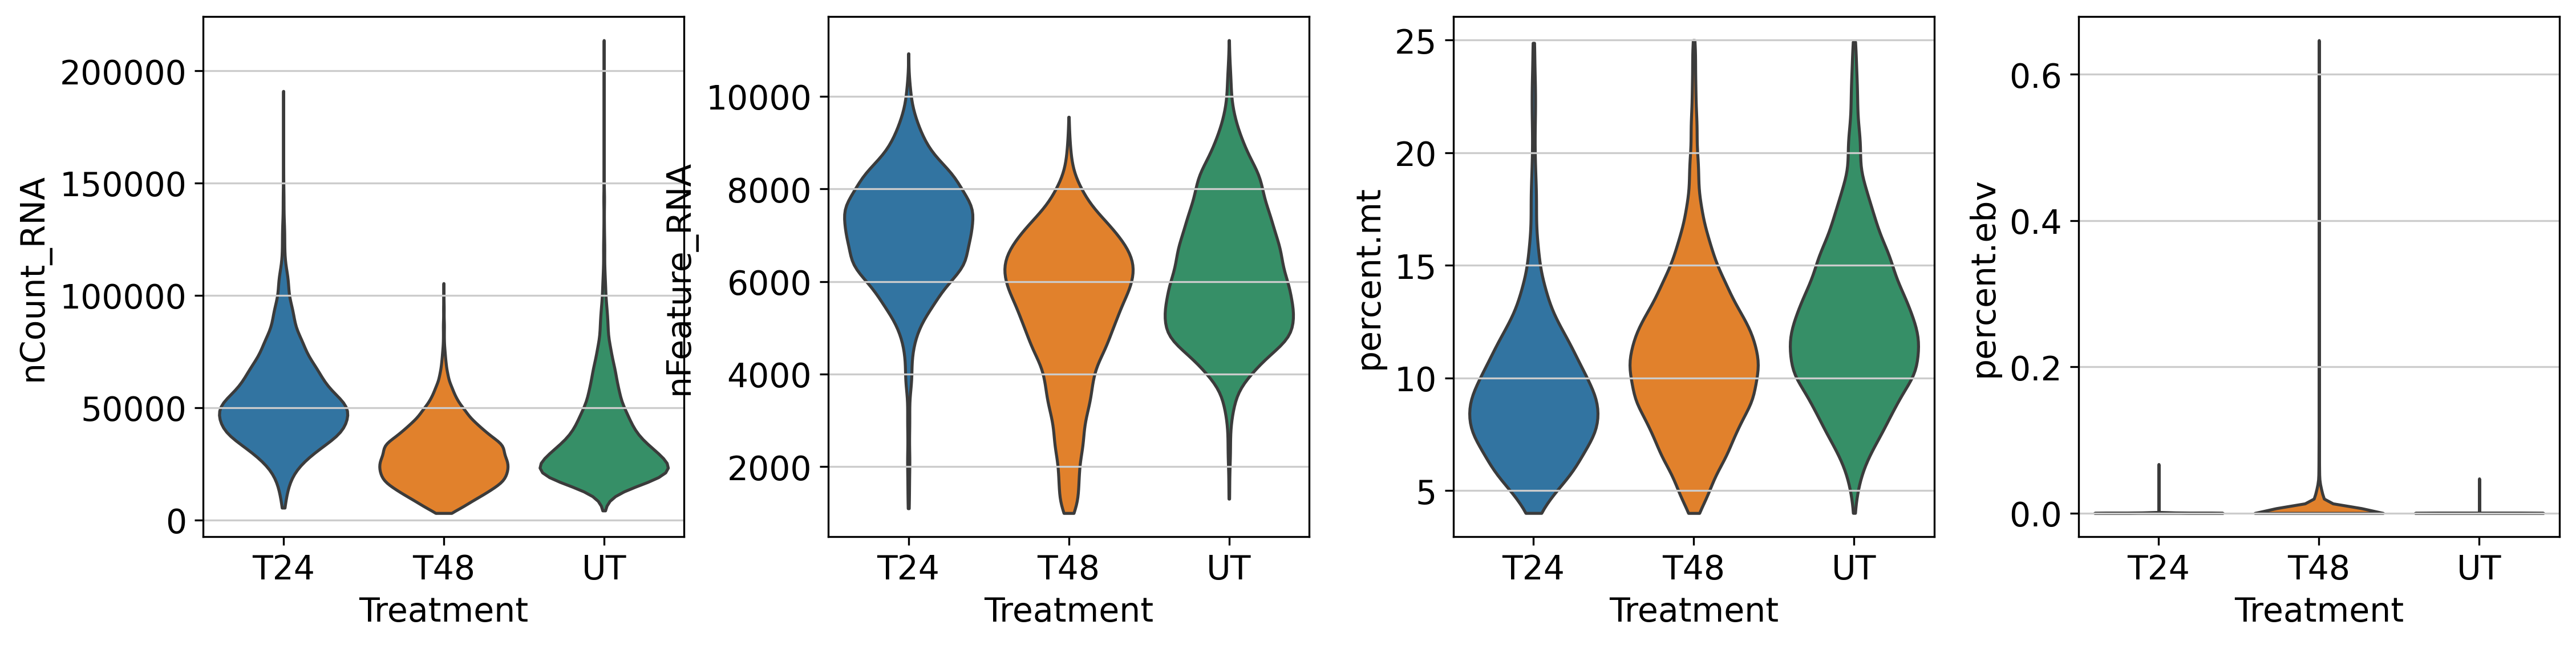

In [49]:
# 5) QC metrics
# If percent.mt is not in annotation, calculate it from mitochondrial genes.

if "percent.mt" not in adata.obs.columns:
    adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    adata.obs["percent.mt"] = adata.obs["pct_counts_mt"]

# nCount_RNA and nFeature_RNA compatibility
if "nCount_RNA" not in adata.obs.columns:
    adata.obs["nCount_RNA"] = np.asarray(adata.X.sum(axis=1)).ravel()
if "nFeature_RNA" not in adata.obs.columns:
    adata.obs["nFeature_RNA"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

qc_cols = ["nCount_RNA", "nFeature_RNA", "percent.mt"]
if "percent.ebv" in adata.obs.columns:
    qc_cols.append("percent.ebv")

groupby = "Treatment" if "Treatment" in adata.obs.columns else None
sc.pl.violin(adata, qc_cols, groupby=groupby, stripplot=False, multi_panel=True)


Original cells: 17741, genes: 27595
filtered out 1 cells that have less than 1000 genes expressed
filtered out 5 genes that are detected in less than 3 cells
After QC cells: 17329, genes: 27590
Treatment
T48    9848
UT     4951
T24    2530
Name: count, dtype: int64
normalizing counts per cell
    finished (0:00:05)
extracting highly variable genes
    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


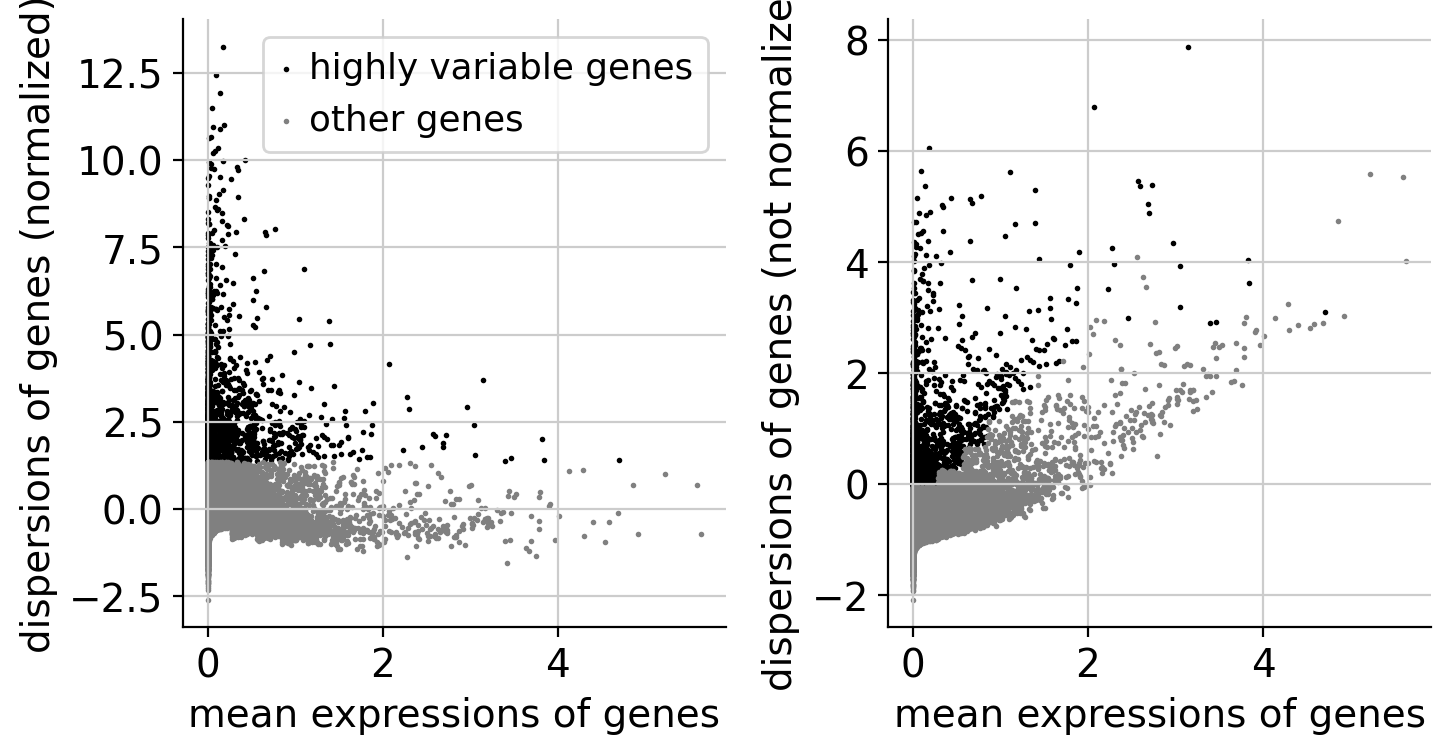

computing PCA
    with n_comps=50
    finished (0:00:02)


/tmp/ipykernel_2873/3085369725.py:23: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata_hvg, log=True, save="_variance_ratio.png")


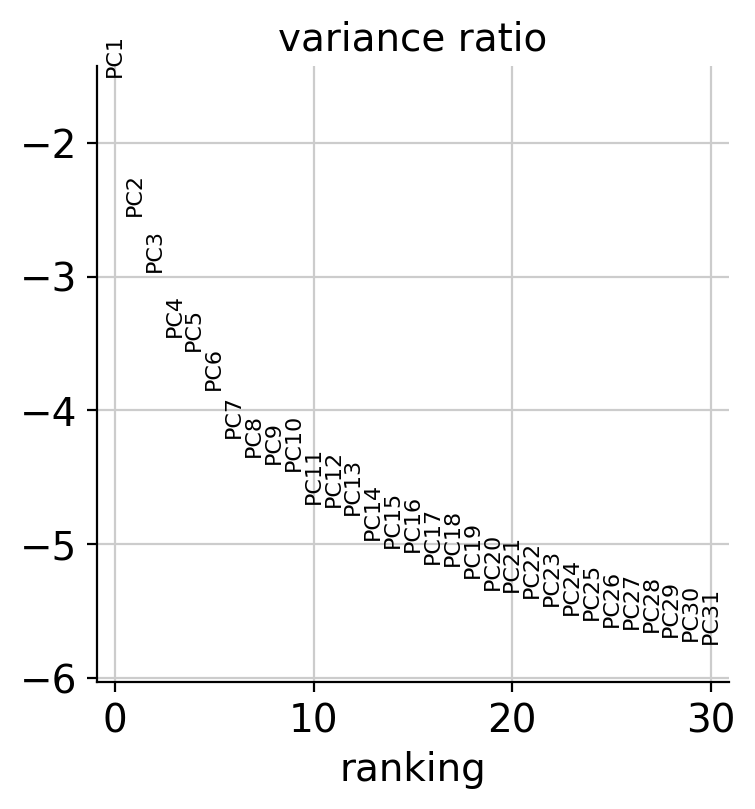

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:33)


/tmp/ipykernel_2873/3085369725.py:26: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hvg, resolution=0.5)


running Leiden clustering
    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:14)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:14)


/tmp/ipykernel_2873/3085369725.py:30: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_hvg, color=color_cols, wspace=0.4, save="_all_cells.png")


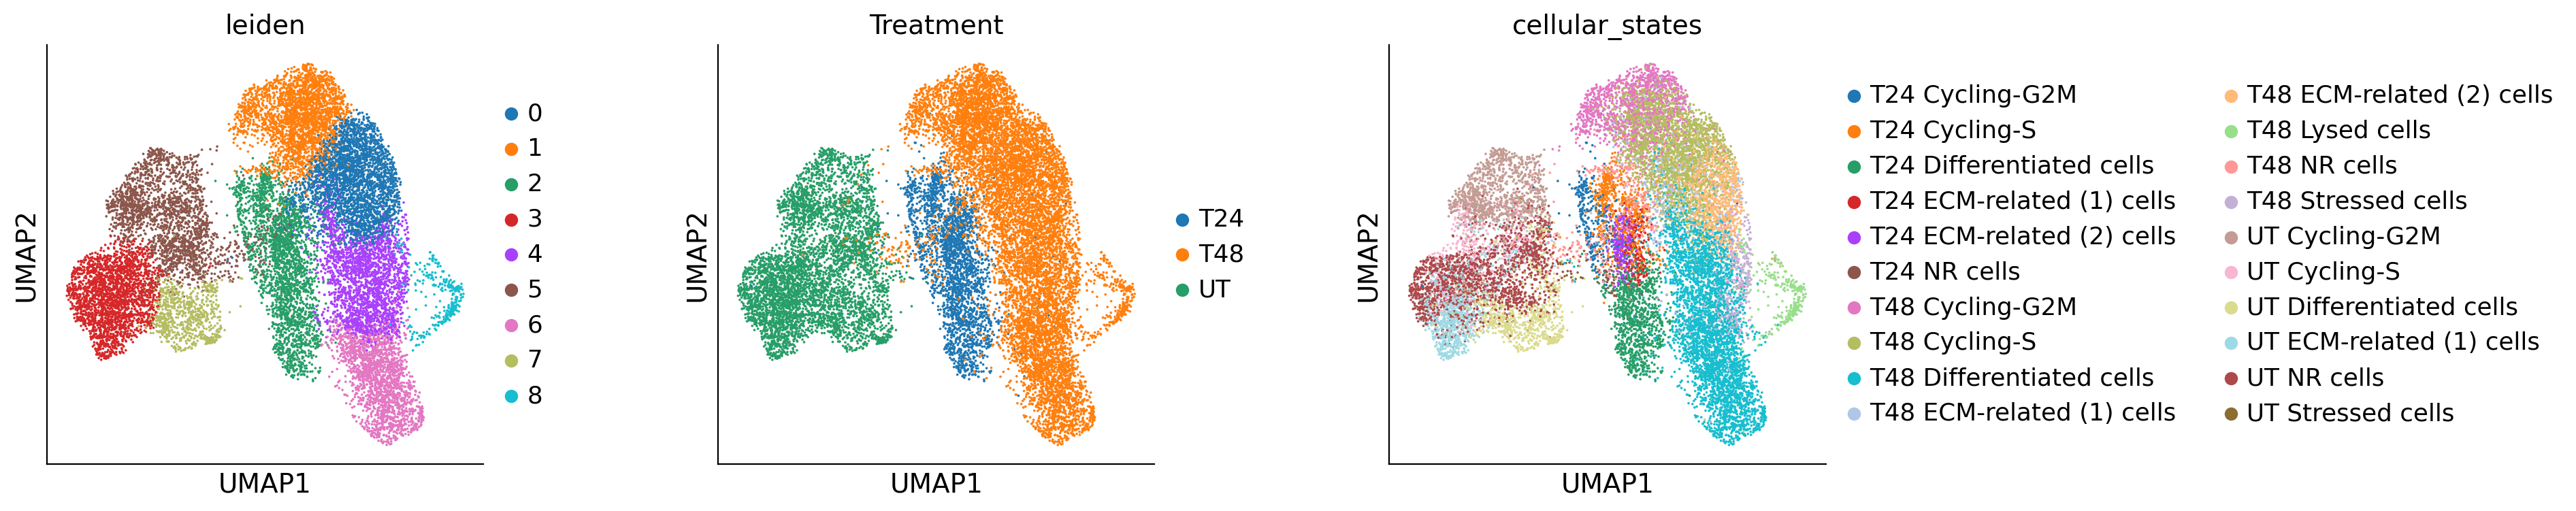

In [51]:
# 6) Filtering, normalization, HVGs, PCA, neighbors, Leiden, UMAP

print(f"Original cells: {adata.n_obs}, genes: {adata.n_vars}")

sc.pp.filter_cells(adata, min_genes=1000)
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[adata.obs["percent.mt"] < 20, :].copy()

print(f"After QC cells: {adata.n_obs}, genes: {adata.n_vars}")
if "Treatment" in adata.obs.columns:
    print(adata.obs["Treatment"].value_counts())

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

adata_hvg = adata[:, adata.var.highly_variable].copy()

sc.tl.pca(adata_hvg, svd_solver="arpack", n_comps=50)
sc.pl.pca_variance_ratio(adata_hvg, log=True, save="_variance_ratio.png")

sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=15, use_rep="X_pca")
sc.tl.leiden(adata_hvg, resolution=0.5)
sc.tl.umap(adata_hvg)

color_cols = [c for c in ["leiden", "Treatment", "cellular_states"] if c in adata_hvg.obs.columns]
sc.pl.umap(adata_hvg, color=color_cols, wspace=0.4, save="_all_cells.png")


UT cells: 4951
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=30


/tmp/ipykernel_2873/3458934840.py:14: UserWarning: `n_top_genes` (=2000) > number of normalized dispersions (=1490), returning all genes with normalized dispersions.
  sc.pp.highly_variable_genes(adata_ut, n_top_genes=min(2000, adata_ut.n_vars), flavor="seurat")
/tmp/ipykernel_2873/3458934840.py:15: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata_ut, n_comps=30, use_highly_variable=True)


    finished (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:12)
Sampling and flocking waypoints...
Time for determining waypoints: 0.0005837122599283855 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.052927613258361816 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9986
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


/tmp/ipykernel_2873/3458934840.py:31: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_ut, color=["pseudotime"], save="_ut_pseudotime.png")


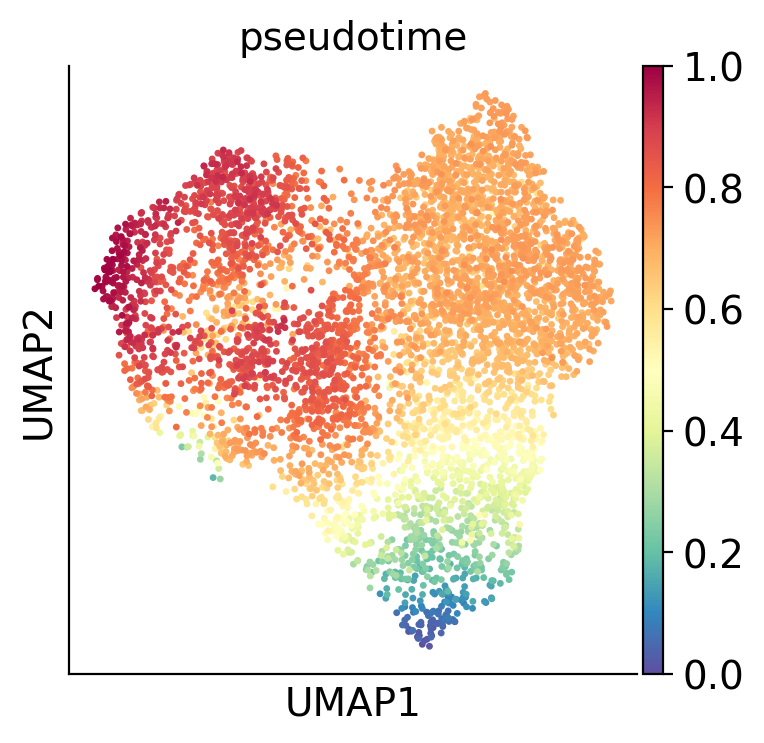

In [52]:
# 7) Optional: UT subset Palantir pseudotime
# Run only if Treatment has UT and palantir is installed.

try:
    import palantir
except ImportError:
    palantir = None
    print("palantir is not installed. Install with: pip install palantir")

if palantir is not None and "Treatment" in adata_hvg.obs.columns and "UT" in set(adata_hvg.obs["Treatment"].astype(str)):
    adata_ut = adata_hvg[adata_hvg.obs["Treatment"].astype(str) == "UT"].copy()
    print("UT cells:", adata_ut.n_obs)

    sc.pp.highly_variable_genes(adata_ut, n_top_genes=min(2000, adata_ut.n_vars), flavor="seurat")
    sc.tl.pca(adata_ut, n_comps=30, use_highly_variable=True)
    sc.pp.neighbors(adata_ut, n_neighbors=30, n_pcs=30, use_rep="X_pca")
    sc.tl.umap(adata_ut)

    dm_res = palantir.utils.run_diffusion_maps(adata_ut)
    ms_data = palantir.utils.determine_multiscale_space(adata_ut)

    if "cellular_states" in adata_ut.obs.columns and "UT Differentiated cells" in set(adata_ut.obs["cellular_states"].astype(str)):
        root_cell = adata_ut.obs[adata_ut.obs["cellular_states"].astype(str) == "UT Differentiated cells"].index[0]
    else:
        root_cell = adata_ut.obs_names[0]
        print("Root state not found. Using first UT cell as root:", root_cell)

    pr_res = palantir.core.run_palantir(ms_data, early_cell=root_cell)
    adata_ut.obs["pseudotime"] = pr_res.pseudotime

    sc.pl.umap(adata_ut, color=["pseudotime"], save="_ut_pseudotime.png")
else:
    print("Skipping Palantir cell.")


calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    1 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    2 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)
Inflammatory_Score genes found: ['CXCL8', 'IL1A', 'TREM1']
computing score 'Inflammatory_Score'
    finished: added
    'Inflammatory_Score', score of gene set (adata.obs).
    149 total control genes are used. (0:00:00)
EMT_score genes found: []
Skipping EMT_score: no genes found in var_names.
Epithelial_score genes found: ['KRT14']
computing score 'Epithelial_score'
    finished: added
    'Epithelial_score', score of gene set (adata.obs).
    49 total control genes are used. (0:00:00)


/tmp/ipykernel_2873/3496356424.py:30: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(target, color=plot_cols, save="_scores_umap.png")


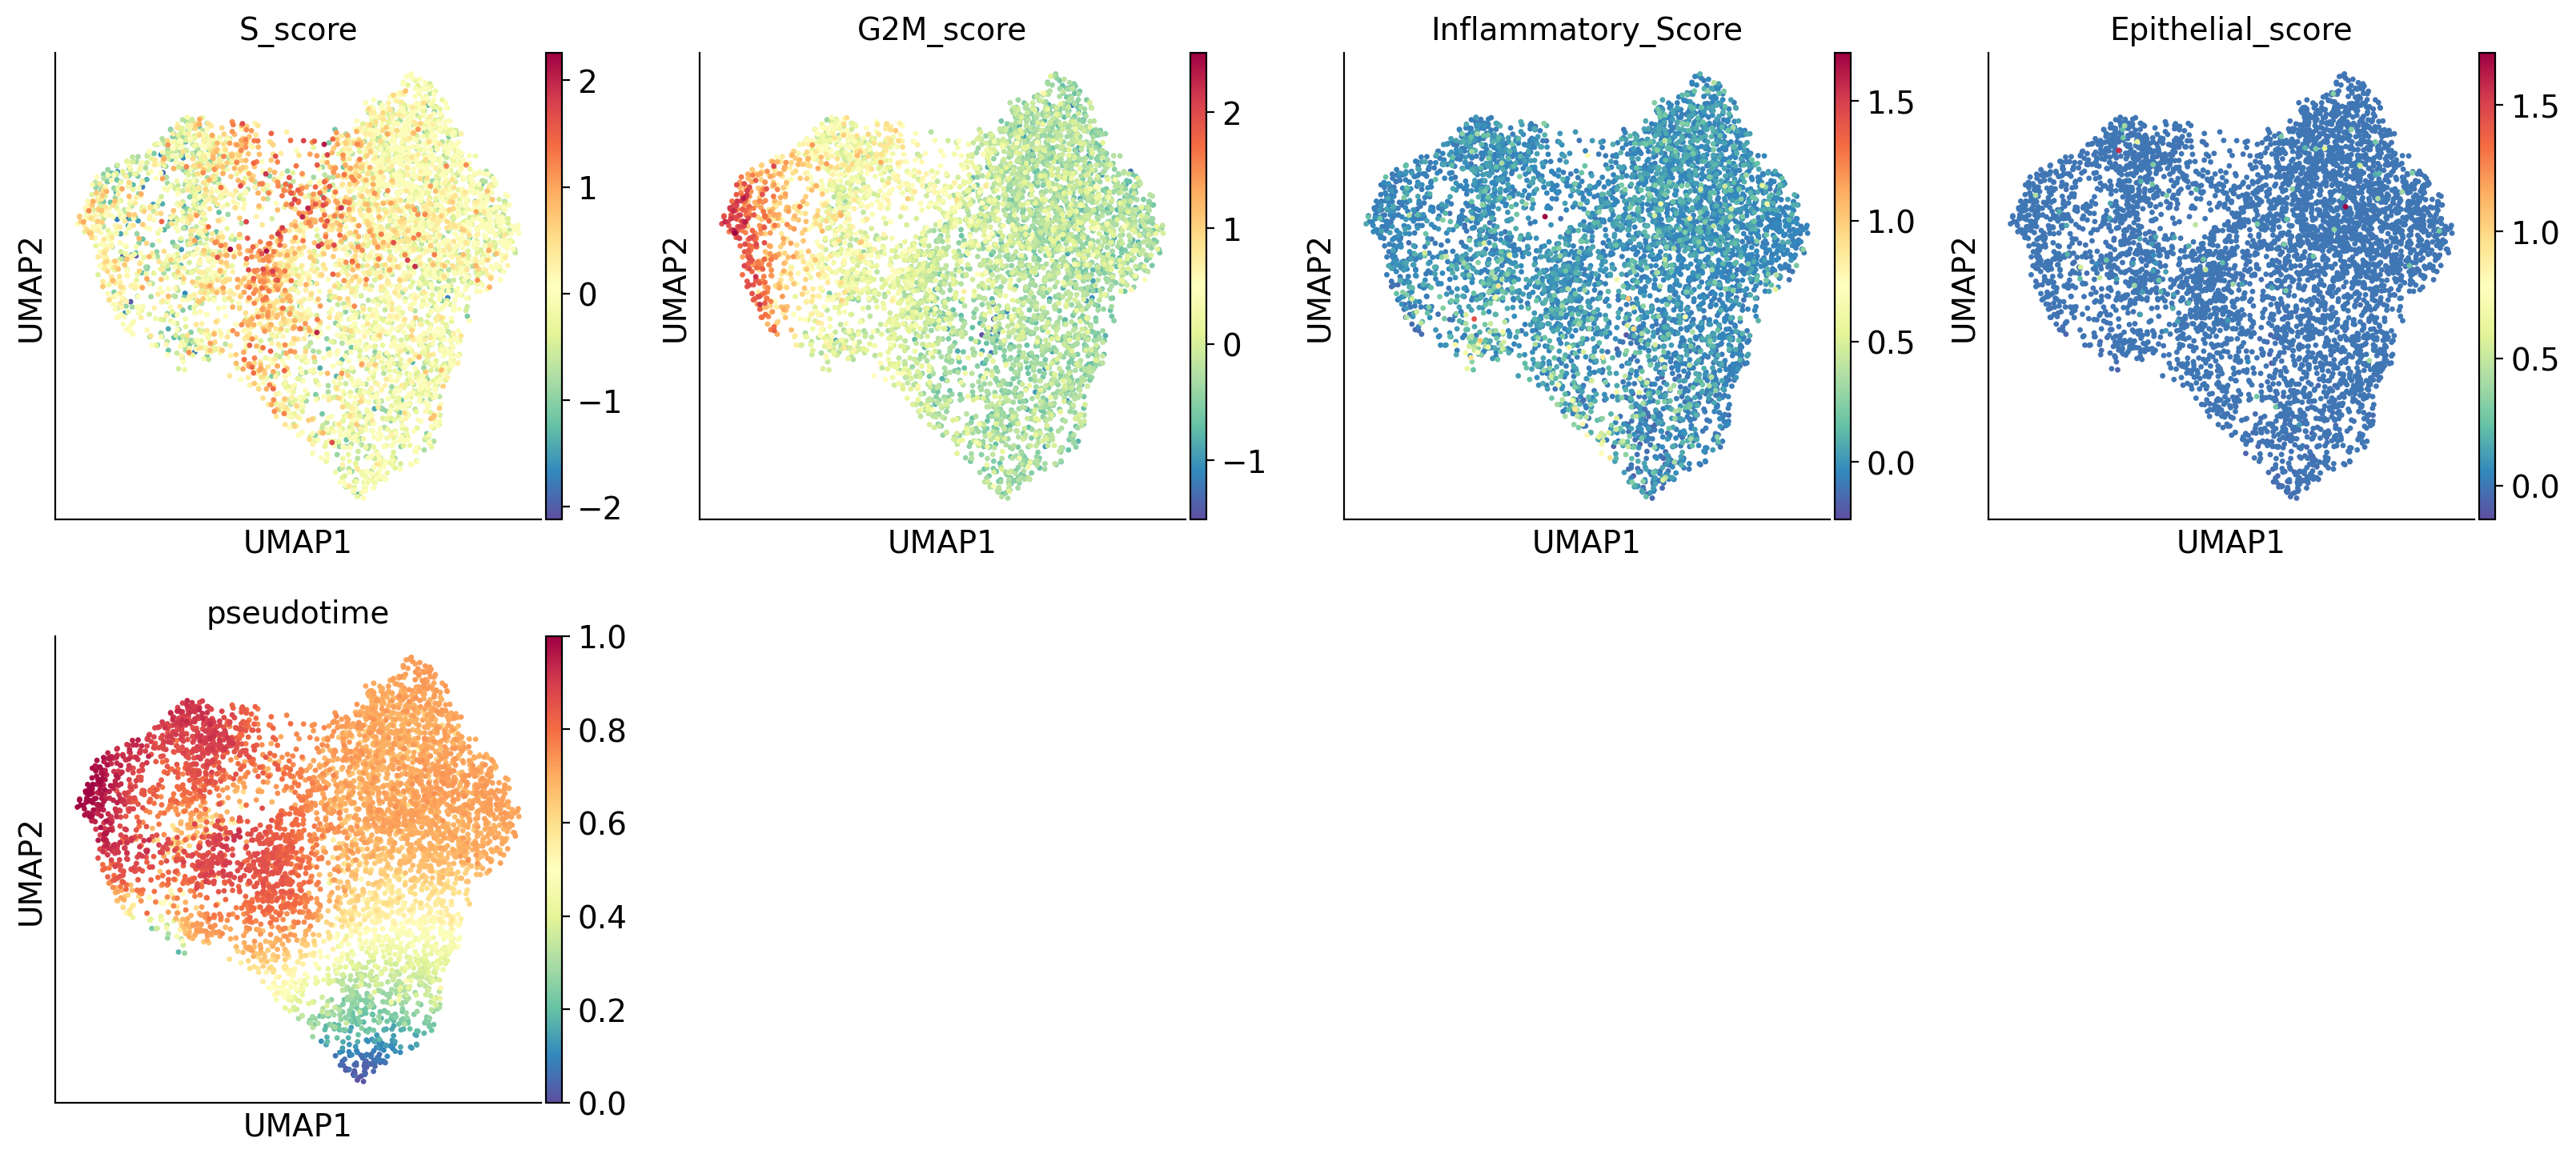

Saved h5ad files.


In [53]:
# 8) Gene-set scoring and save outputs

def safe_score_genes(adata_obj, genes, score_name):
    genes = [g for g in genes if g in adata_obj.var_names]
    print(score_name, "genes found:", genes)
    if len(genes) == 0:
        print(f"Skipping {score_name}: no genes found in var_names.")
        return False
    sc.tl.score_genes(adata_obj, gene_list=genes, score_name=score_name)
    return True

target = adata_ut if "adata_ut" in globals() else adata_hvg

s_genes = ["MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2","MCM6","CDCA7","DTL","PRIM1","UHRF1","HELLS","RFC2","RPA2","NASP","RAD51AP1","GMNN"]
g2m_genes = ["HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80","CKS2","NUF2","CKS1B","MKI67","TMPO","CENPF","TACC3","SMC4","CCNB2"]

s_found = [g for g in s_genes if g in target.var_names]
g2m_found = [g for g in g2m_genes if g in target.var_names]
if s_found and g2m_found:
    sc.tl.score_genes_cell_cycle(target, s_genes=s_found, g2m_genes=g2m_found)
else:
    print("Skipping cell-cycle scoring because S or G2M genes were not found.")

safe_score_genes(target, ["CXCL8", "IL1A", "TREM1", "CXCR2", "CSF3R"], "Inflammatory_Score")
safe_score_genes(target, ["VIM", "FN1", "SNAI1", "TWIST1", "ZEB1"], "EMT_score")
safe_score_genes(target, ["EPCAM", "KRT5", "KRT14", "KRT17", "KRT19"], "Epithelial_score")

plot_cols = [c for c in ["S_score", "G2M_score", "Inflammatory_Score", "EMT_score", "Epithelial_score", "pseudotime"] if c in target.obs.columns]
if plot_cols:
    sc.pl.umap(target, color=plot_cols, save="_scores_umap.png")

adata_hvg.write("adata_all_cells_computed.h5ad")
if "adata_ut" in globals():
    adata_ut.write("adata_ut_palantir_completed.h5ad")

print("Saved h5ad files.")
